# Customer Segmentation using K-Means Clustering

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('Mall_Customers.csv')
df.head()


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## Data Preprocessing

In [2]:
data = df[['Annual Income (k$)', 'Spending Score (1-100)']]

scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)


## Elbow Method

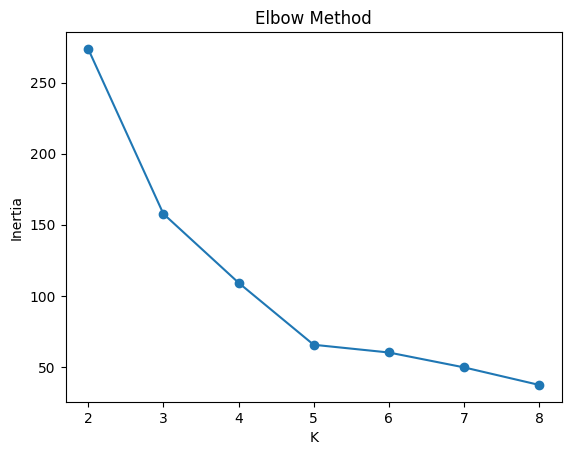

In [3]:
inertia = []

for k in range(2, 9):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

plt.plot(range(2, 9), inertia, marker='o')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()


## K-Means Clustering

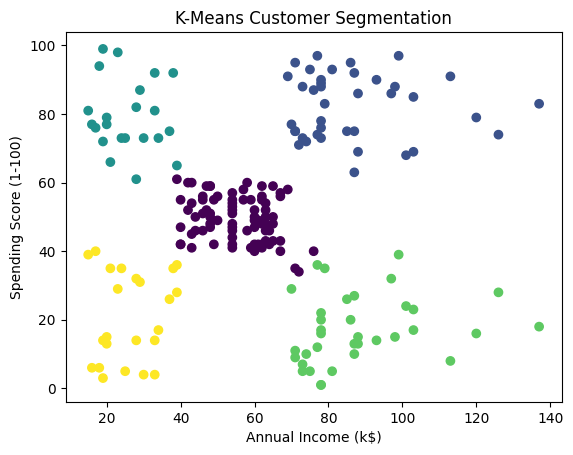

In [4]:
optimal_k = 5

kmeans = KMeans(n_clusters=optimal_k, random_state=42)
clusters = kmeans.fit_predict(scaled_data)

plt.scatter(
    data['Annual Income (k$)'],
    data['Spending Score (1-100)'],
    c=clusters
)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('K-Means Customer Segmentation')
plt.show()


## DBSCAN Comparison

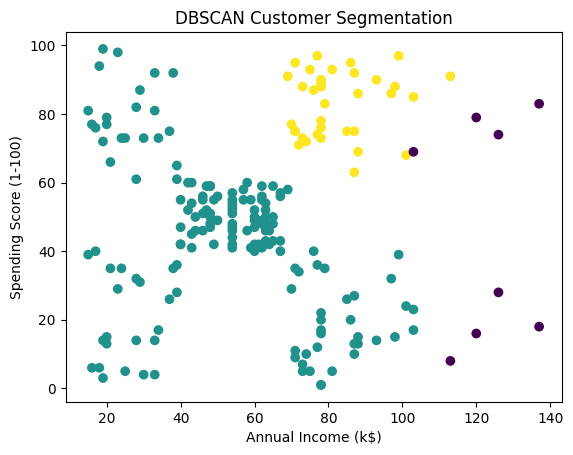

In [5]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_clusters = dbscan.fit_predict(scaled_data)

plt.scatter(
    data['Annual Income (k$)'],
    data['Spending Score (1-100)'],
    c=dbscan_clusters
)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('DBSCAN Customer Segmentation')
plt.show()


## Analysis and Business Insights


The Mall Customer dataset was segmented using K-Means clustering based on annual income and spending score. Data preprocessing included selecting relevant features and applying standard scaling to normalize values. The Elbow Method identified K=5 as the optimal number of clusters because it balanced lower inertia with model simplicity. 

The resulting clusters revealed different customer behaviors. One segment represented high-income and high-spending customers, who are valuable targets for premium products and loyalty programs. Another cluster contained high-income but low-spending customers, indicating opportunities for personalized marketing campaigns. Moderate-income and moderate-spending customers form stable customer groups, while low-income low-spending customers are more price sensitive and may respond better to discounts and offers.

DBSCAN was also tested for comparison. Unlike K-Means, DBSCAN detects noise and density-based patterns without requiring a fixed number of clusters. However, for this dataset, K-Means produced clearer and more interpretable customer segments, making it more suitable for business decision-making and marketing strategies.
